In [1]:
import pandas as pd
import data_analysis_utils as da
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

dataset = pd.read_csv('Placement.csv')
dataset


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [2]:
dataset.drop('sl_no', axis=1, inplace=True)
quan, qual = da.Univariate.quanQual(dataset)


## 1)Replace the NaN values with correct value. And justify why you have chosen the same.



### Since the missing values in 'salary' column is because the 'status is 'Not Placed' we will give value 0 for salary  


In [3]:
dataset.isna().sum()


gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [4]:
dataset['status'].value_counts()
dataset[dataset['status']=='Not Placed']['salary'].sum()


np.float64(0.0)

In [5]:

# dataset.drop('sl_no', axis=1, inplace=True)

dataset.loc[dataset['status']=='Not Placed', 'salary'] = 0

dataset.isna().mean()


gender            0.0
ssc_p             0.0
ssc_b             0.0
hsc_p             0.0
hsc_b             0.0
hsc_s             0.0
degree_p          0.0
degree_t          0.0
workex            0.0
etest_p           0.0
specialisation    0.0
mba_p             0.0
status            0.0
salary            0.0
dtype: float64

## 2)How many of them are not placed?

### 67 of them are Not Placed

In [6]:
dataset['status'].value_counts()


status
Placed        148
Not Placed     67
Name: count, dtype: int64

## 3)Find the reason for non placement from the dataset?

### The overall placement observations from dataset are:

1. Having work experience and Mkt&Fin specialisation greatly improves placement chances.
2. Arts stream and Other degree types are at a higher risk of non-placement.
3. Female candidates face a slightly higher non-placement rate than males.

In [7]:
quan, qual = da.Univariate.quanQual(dataset)



for colName in qual: 

    # Non Placement rate %
    non_placement_rate = (
        dataset[dataset['status'] == 'Not Placed']
        .groupby(colName).size() / dataset.groupby(colName).size() * 100
    )
    print(f"\nNon Placement Rate % for {colName}")
    print(non_placement_rate.round(2))
    print('\n=================')




Non Placement Rate % for gender
gender
F    36.84
M    28.06
dtype: float64


Non Placement Rate % for ssc_b
ssc_b
Central    32.76
Others     29.29
dtype: float64


Non Placement Rate % for hsc_b
hsc_b
Central    32.14
Others     30.53
dtype: float64


Non Placement Rate % for hsc_s
hsc_s
Arts        45.45
Commerce    30.09
Science     30.77
dtype: float64


Non Placement Rate % for degree_t
degree_t
Comm&Mgmt    29.66
Others       54.55
Sci&Tech     30.51
dtype: float64


Non Placement Rate % for workex
workex
No     40.43
Yes    13.51
dtype: float64


Non Placement Rate % for specialisation
specialisation
Mkt&Fin    20.83
Mkt&HR     44.21
dtype: float64


Non Placement Rate % for status
status
Not Placed    100.0
Placed          NaN
dtype: float64



## 4)What kind of relation between salary and mba_p

### Salary and mba_p have a heteroscedastic relation, meaning the variability in salary increases as mba_p increases.

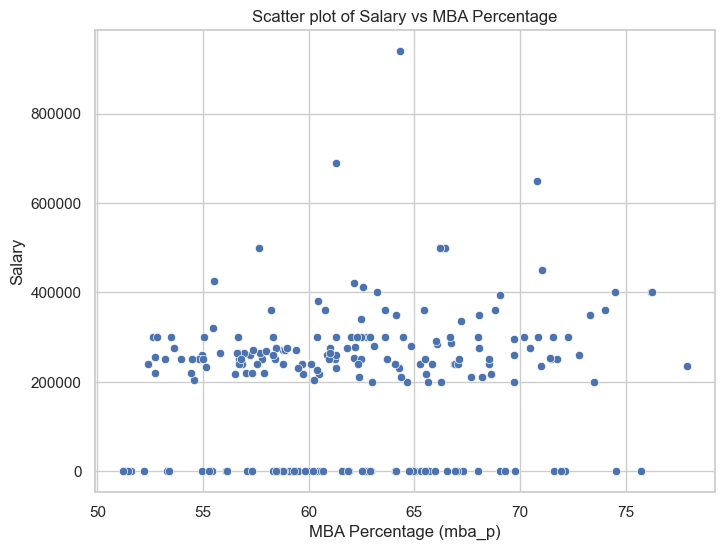

In [8]:


plt.figure(figsize=(8,6))
sns.scatterplot(x='mba_p', y='salary', data=dataset)
plt.title("Scatter plot of Salary vs MBA Percentage")
plt.xlabel("MBA Percentage (mba_p)")
plt.ylabel("Salary")
plt.show()


## 5)Which specialization is getting minimum salary?

### Marketing and HR is getting minimum salary 



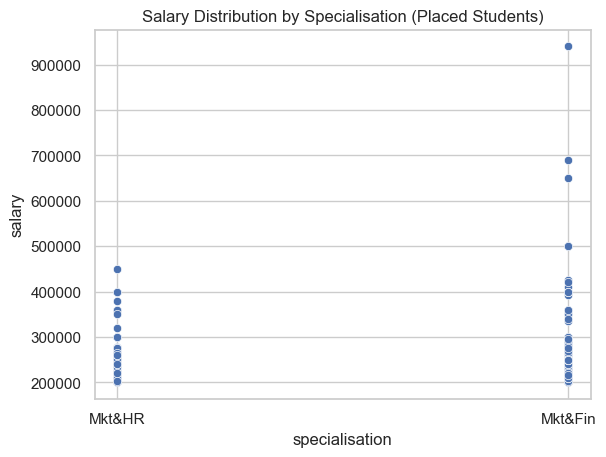

  specialisation    salary
0        Mkt&Fin  298853.0
1         Mkt&HR  270377.0


In [9]:
sns.scatterplot(x='specialisation', y='salary', data=dataset[dataset['status']=='Placed'])
plt.title("Salary Distribution by Specialisation (Placed Students)")
plt.show()

print(dataset[dataset['status']=='Placed'].groupby('specialisation')['salary'].mean().round().reset_index())


## 6)How many of them getting above 500000 salary?

### 3 of them are getting above 5,00,000 Salary

In [10]:
dataset[dataset['salary']>500000]


,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
119,M,60.8,Central,68.40,Central,Commerce,64.6,Comm&Mgmt,Yes,82.66,Mkt&Fin,64.34,Placed,940000.0
150,M,71.0,Central,58.66,Central,Science,58.0,Sci&Tech,Yes,56.00,Mkt&Fin,61.30,Placed,690000.0
177,F,73.0,Central,97.00,Others,Commerce,79.0,Comm&Mgmt,Yes,89.00,Mkt&Fin,70.81,Placed,650000.0


## 7)Test the Analysis of Variance between etest_p and mba_p at signifance level 5%.(Make decision using Hypothesis Testing)

In [ ]:
# Null Hypothesis: There is no significant difference in means of etest_p and mba_p
# Alternative Hypothesis: There is a significant difference in means of etest_p and mba_p

import scipy.stats as stats

# Run one-way ANOVA
test = stats.f_oneway(dataset['etest_p'], dataset['mba_p'])


print(test)
if test[1] < 0.05:
    print("\np-value:", test[1].round(3), 'hence, we reject the null hypothesis (significant difference)..')
else:
    print("\np-value:", test[1].round(3), 'hence, we fail to reject the null hypothesis (no significant difference)..')


F_onewayResult(statistic=np.float64(98.64487057324706), pvalue=np.float64(4.672547689133573e-21))

p-value: 0.0 hence, we reject the null hypothesis (significant effect)..


## 8)Test the similarity between the degree_t(Sci&Tech) and specialisation(Mkt&HR) with respect to salary  at significance level of 5%.(Make decision using Hypothesis Testing)

In [32]:
# Null Hypothesis: There is no significant difference between degree_t and Specialization on Salary
# Alternative Hypothesis: There is a significant difference between degree_t and Specialization on Salary

import statsmodels.api as sm
from statsmodels.formula.api import ols


model = ols('salary ~ C(degree_t) + C(specialisation) + C(degree_t):C(specialisation)', data=dataset).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

for factor in anova_table.index[:-1]:  # exclude 'Residual'
    p_value = anova_table.loc[factor, "PR(>F)"]
    if p_value < 0.05:
        print(f"\nFor {factor}, p-value = {p_value:.3f}, hence we Reject null hypothesis (significant effect).")
    else:
        print(f"\nFor {factor}, p-value = {p_value:.3f}, hence we Fail to reject null hypothesis (no significant effect).")


                                     sum_sq     df          F    PR(>F)
C(degree_t)                    7.197891e+10    2.0   1.616216  0.201122
C(specialisation)              3.815378e+11    1.0  17.134112  0.000051
C(degree_t):C(specialisation)  1.101264e+10    2.0   0.247278  0.781152
Residual                       4.653956e+12  209.0        NaN       NaN

For C(degree_t), p-value = 0.201, hence we Fail to reject null hypothesis (no significant effect).

For C(specialisation), p-value = 0.000, hence we Reject null hypothesis (significant effect).

For C(degree_t):C(specialisation), p-value = 0.781, hence we Fail to reject null hypothesis (no significant effect).


## 9)Convert the normal distribution to standard normal distribution for salary column

Salary column before conversion


<Axes: xlabel='salary', ylabel='Count'>

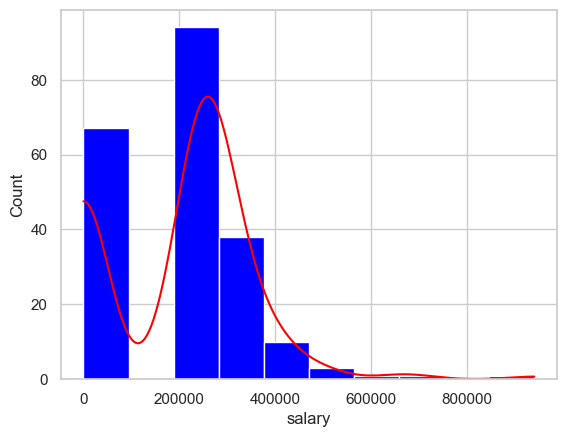

In [30]:
print('Salary column before conversion')
sns.histplot(dataset['salary'],kde=True,facecolor='blue',color='red')





Average of z-scores: -0.0

Standard deviation of z-scores: 1.0


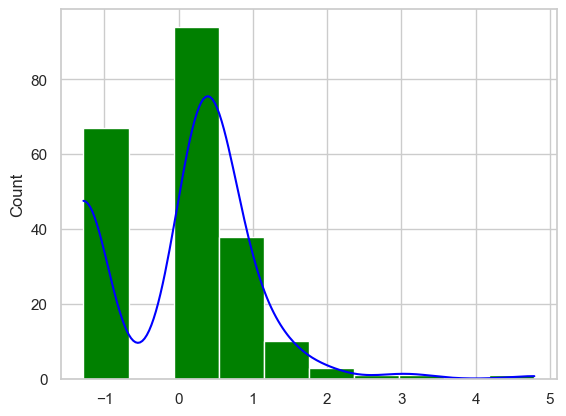

In [23]:
avg_z, std_z = da.NormalDistribution.stdNBgraph(dataset['salary'], sample_mean, sample_std)

print("\nAverage of z-scores:", avg_z.round(3))
print("\nStandard deviation of z-scores:", std_z.round(3))


## 10)What is the probability Density Function of the salary range from 700000 to 900000?

Column: salary

Mean = 198702.326, Standard Deviation = 154780.927

The area between range (700000,800000): Approximately : 0.001, Actually: 0.001


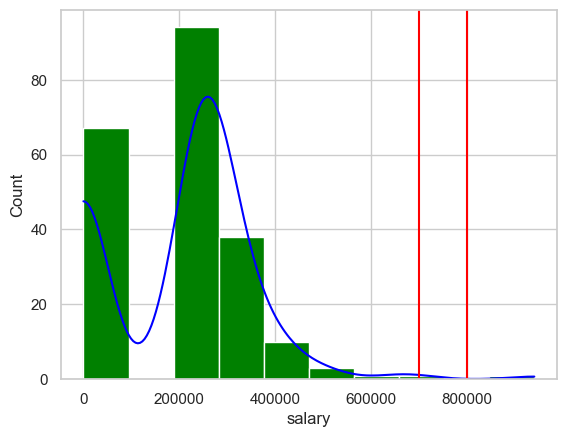

In [13]:
startrange = 700000
endrange = 800000
perc_lookup = 0
columnName = 'salary'
sample_mean, sample_std, appx_prob, actual_prob, ecdf = da.NormalDistribution.get_pdf_probability(dataset[columnName], startrange, endrange, perc_lookup)

print('Column: {}'.format(columnName))
print('\nMean = %.3f, Standard Deviation = %.3f' % (sample_mean, sample_std))
print("\nThe area between range ({},{}): Approximately : {:.3f}, Actually: {:.3f}".format(startrange, endrange, appx_prob, actual_prob))


## 11)Test the similarity between the degree_t(Sci&Tech)with respect to etest_p and mba_p at significance level of 5%.(Make decision using Hypothesis Testing)

In [36]:
# 4. MBA Percentage vs etest Percentage for Sci & Tech Degree Holders

# Null Hypothesis: There is no significant difference between MBA percentage and etest percentage for Sci & Tech Degree Holders
# Alternative Hypothesis: There is a significant difference between MBA percentage and etest percentage for Sci & Tech Degree Holders
from scipy.stats import ttest_rel

mba = dataset[dataset['degree_t'] == 'Sci&Tech']['mba_p']
etest = dataset[dataset['degree_t'] == 'Sci&Tech']['etest_p']

test = ttest_rel(mba, etest)

print(test)
if test[1] < 0.05:
    print("\np-value:", test[1].round(3), 'hence, we reject the null hypothesis (significant effect).')
else:
    print("\np-value:", test[1].round(3), 'hence, we fail to reject the null hypothesis (no significant effect).')


TtestResult(statistic=np.float64(-5.0049844583693615), pvalue=np.float64(5.517920600505392e-06), df=np.int64(58))

p-value: 0.0 hence, we reject the null hypothesis (significant effect).


## 12)Which parameter is highly correlated with salary?

### All parameters are weekly correlated with salary, out of which highly correlated are etest_p and mba_p

In [ ]:
dataset[quan].corr()['salary'].sort_values(ascending=False)


salary      1.000000
etest_p     0.178307
mba_p       0.175013
hsc_p       0.076819
ssc_p       0.035330
degree_p   -0.019272
Name: salary, dtype: float64

## 13) plot  any useful graph and explain it.

### Observations from the Pair plot

1. There is a positive correlation among the academic percentages (ssc_p, hsc_p, degree_p, etest_p, mba_p). Students who perform well in school and undergrad tend to score well in MBA too.
2. Salary does not show a strong linear relationship with these percentages — it looks more scattered, meaning salary is influenced by other factors.

In short: Academic performance is somewhat consistent across stages, but high academic scores don’t directly guarantee a higher salary.

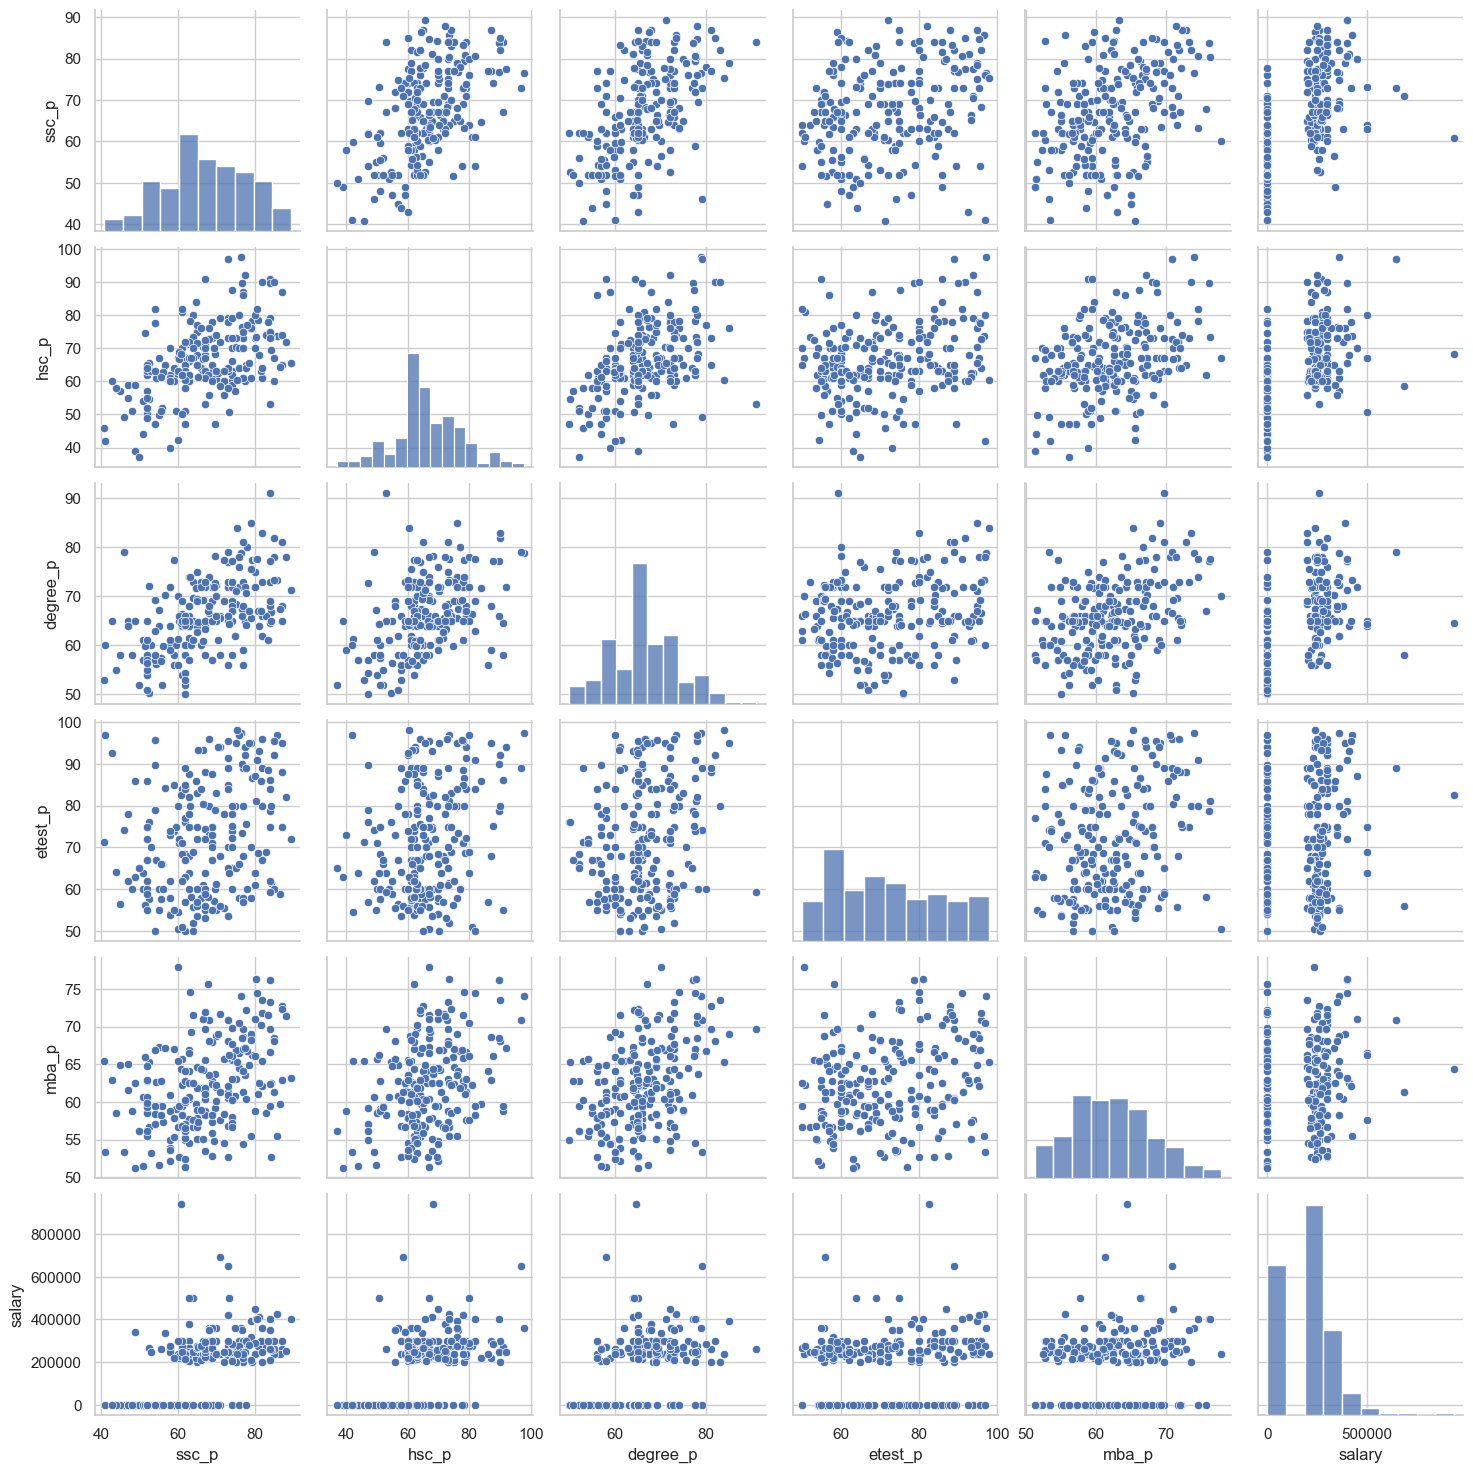

In [37]:
sns.pairplot(dataset)
